---
title: "MuSiC"
output: html_document
date: "2026-03-26"
---



In [ ]:
knitr::opts_chunk$set(echo = TRUE)


In [2]:
library(ggplot2)
library(ggrepel)
library(ggpubr)
library(stringr)
library(MASS)
library(RColorBrewer)
library(DESeq2)
library(viridis)
library(ggpointdensity)
library(tidyverse)
library(data.table)
library(pheatmap)
library(ComplexHeatmap)
library(UpSetR)
library(readxl)
library(ggsci)
library(ggpointdensity)
library(ggprism)
library(ragg)
library(edgeR)
library(MuSiC)
library(Seurat)
theme_set(theme_classic(base_size = 15))

personal_path = "/fh/working/sun_w/sshen/MorPhiC"
path = "/fh/fast/sun_w/MorPhiC/data/MorPhiC_exchange_experiment/"
dat_path = file.path(path, "DRACC-processed/JAX_exchange_experiment_DRACC_processed_August2025/Tables")
# Load necessary libraries (data.table is highly recommended for large .gz files)
library(Seurat)
library(Matrix)
library(data.table) # Essential for loading the dense scaled CSV quickly

# 0. Define the folder path
data_dir <- "/fh/working/sun_w/sshen/MorPhiC/PrS_WT_Normoxia_D4to6/"

# 1. Load Metadata
metadata <- read.csv(paste0(data_dir, "export_metadata.csv"), row.names = 1)

# 2. Load Raw Log-Transformed Data
raw_mat <- readMM(paste0(data_dir, "export_raw_log_matrix.mtx"))
raw_mat <- as(raw_mat, "CsparseMatrix") # Force it into column-compressed format for fast math
rownames(raw_mat) <- read.csv(paste0(data_dir, "export_genes.csv"), header = FALSE)$V1
colnames(raw_mat) <- read.csv(paste0(data_dir, "export_barcodes.csv"), header = FALSE)$V1

# ---------------------------------------------------------
# 3. Transform Log-Data Back to Integer Counts (For MuSiC)
# ---------------------------------------------------------
# Un-log the values in the sparse matrix
unlogged_data <- exp(raw_mat@x) - 1

# In a dgCMatrix, columns are cells. @p contains the column pointers.
# This tells us exactly how many expressed genes each cell has.
counts_per_cell <- diff(raw_mat@p)
cell_group_ids <- rep(1:length(counts_per_cell), counts_per_cell)

# Find the scale factor (minimum non-zero value) per cell
min_vals_per_cell <- tapply(unlogged_data, cell_group_ids, min)

# Map the scale factors back (using as.character protects against empty cells)
scale_factors <- min_vals_per_cell[as.character(cell_group_ids)]

# Divide and round to get true integers
integer_data <- as.numeric(round(unlogged_data / scale_factors))

# Rebuild the pristine integer matrix
counts_mat <- sparseMatrix(
  i = raw_mat@i + 1,        # 1-based row indices
  p = raw_mat@p,            # Column pointers
  x = integer_data,
  dims = dim(raw_mat),
  dimnames = list(rownames(raw_mat), colnames(raw_mat))
)

# ---------------------------------------------------------
# 4. Load Scaled Data
# ---------------------------------------------------------
# fread is incredibly fast. We convert it straight to a matrix.
scaled_mat <- as.matrix(fread(paste0(data_dir, "export_scaled_data.csv")), rownames = 1)

# ---------------------------------------------------------
# 5. Build Final Seurat Object
# ---------------------------------------------------------
# Initialize with the rescued integer counts (Perfect for MuSiC)
sc_ref <- CreateSeuratObject(
  counts = counts_mat, 
  project = "Normoxia_D4to6", 
  meta.data = metadata
)

# Inject the original log-normalized data into the 'data' layer.
# This is a huge time-saver: you don't need to run NormalizeData() in R anymore!
sc_ref <- SetAssayData(sc_ref, layer = "data", new.data = raw_mat)

# Inject Scaled Data
sc_ref <- SetAssayData(sc_ref, layer = "scale.data", new.data = scaled_mat)

# ---------------------------------------------------------
# 6. Load and Inject Embeddings
# ---------------------------------------------------------
pca_coords <- as.matrix(read.csv(paste0(data_dir, "export_pca.csv"), row.names = 1))
colnames(pca_coords) <- paste0("PC_", 1:ncol(pca_coords))
sc_ref[["pca"]] <- CreateDimReducObject(embeddings = pca_coords, key = "PC_", assay = "RNA")

umap_coords <- as.matrix(read.csv(paste0(data_dir, "export_umap.csv"), row.names = 1))
colnames(umap_coords) <- paste0("UMAP_", 1:ncol(umap_coords))
sc_ref[["umap"]] <- CreateDimReducObject(embeddings = umap_coords, key = "UMAP_", assay = "RNA")

# Verify everything is in its right place
print(sc_ref)


An object of class Seurat 
18082 features across 20818 samples within 1 assay 
Active assay: RNA (18082 features, 0 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap


Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”
PC_ 1 
Positive:  ERVV-1, TNFRSF1B, ERVV-2, CGA, HOPX, SGK1, SDC1, TRPV2, KRT23, ABTB2 
	   SLC43A2, FOXO6, CCR7, SLC13A4, LYPD3, MUC15, FAM49A, S100P, CYP11A1, NUCB2 
	   CPM, CDH5, HEXIM1, SLC19A1, SEMA7A, PRKCZ, HSPB1, PGF, FHDC1, SIAH1 
Negative:  SOX4, TUBB2B, CDH3, TAGLN, LRATD2, SPP1, FN1, CCND2, PODXL, ID3 
	   BAMBI, GABRP, PKDCC, GADD45A, CYP1B1, NPPB, SLC4A8, MT1X, GAS7, KCTD12 
	   THBS1, MT2A, NES, F3, FST, LOXL2, ACTC1, EPSTI1, DKK3, CCN2 
PC_ 2 
Positive:  DLX3, LRATD1, ISM2, CAPN6, GCM1, RASA1, PPARD, ITGA1, PAGE4, EPO 
	   CCNE1, XAGE2, SLC27A2, ZBTB7C, EZH2, ADAMTS1, TTC39A, GATA2, ST8SIA4, PPIF 
	   CSF3R, CAV1, TET3, GBP2, CTSH, JAM3, BHLHE41, REEP1, ST3GAL4, PGF 
Negative:  LRATD2, FLNC, PODXL, DPYSL3, CDH3, ACKR3, S100A6, CPE, IGFBP7, BAMBI 
	   NES, GAS7, TUBB2B, AXL, L

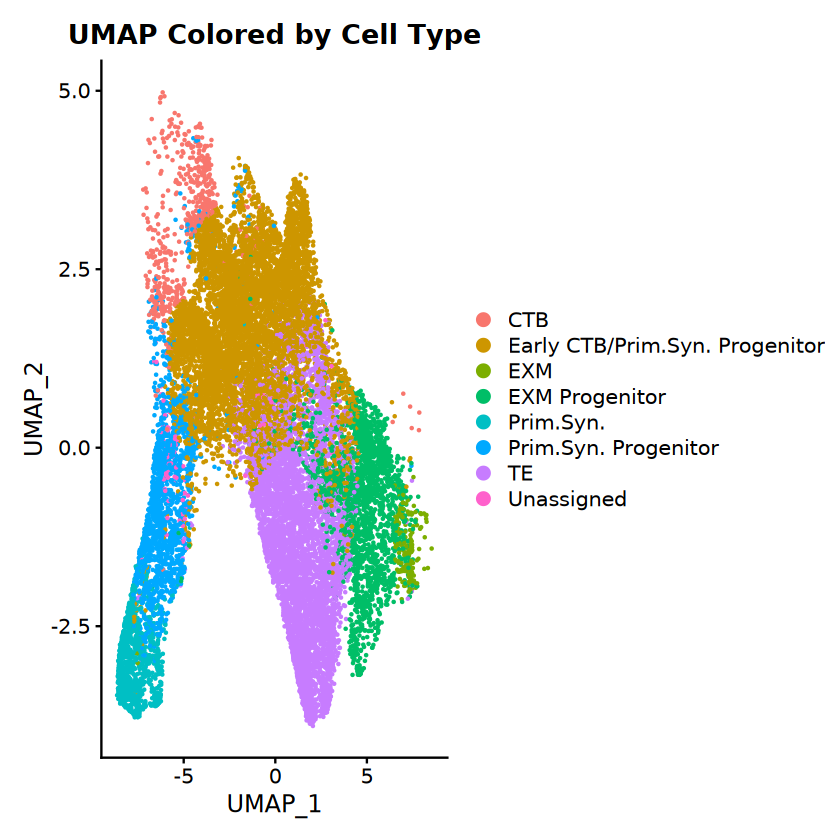

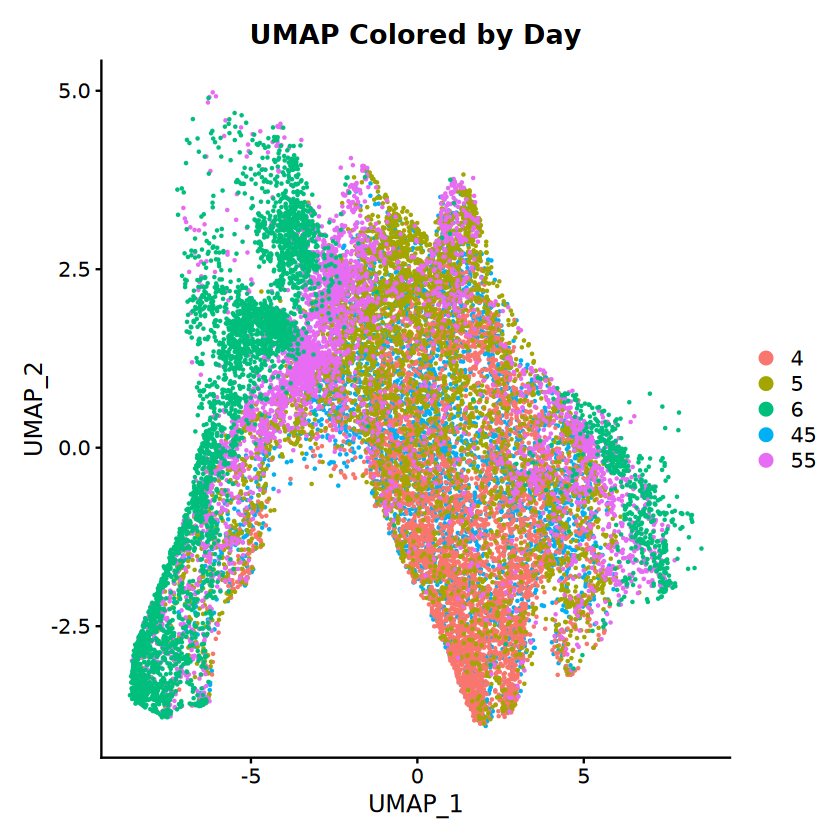

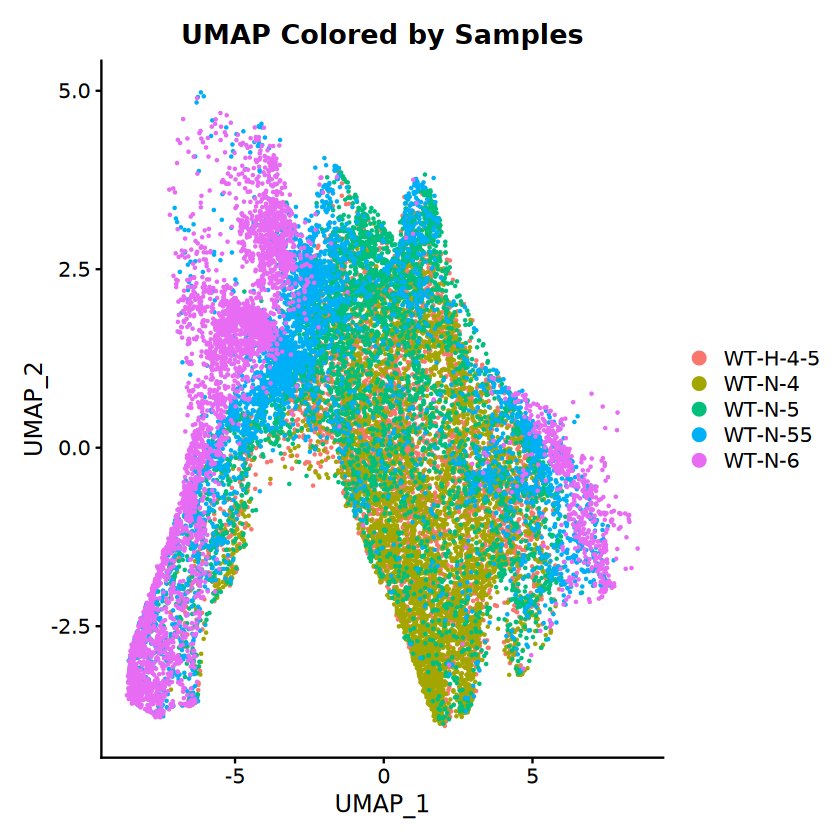

In [3]:
# 0. Remove Mitochondrial Genes
non_mt_genes <- grep(pattern = "^MT-", x = rownames(sc_ref), invert = TRUE, value = TRUE)

# Subset the Seurat object to keep only those non-MT genes
sc_ref <- subset(sc_ref, features = non_mt_genes)

# 1. Normalize Data
sc_ref = NormalizeData(sc_ref, scale.factor = 10000)

# 2. Find Highly Variable Features
# Identifies genes that exhibit high cell-to-cell variation
sc_ref <- FindVariableFeatures(sc_ref, selection.method = "vst", nfeatures = 2000)

sc_ref = ScaleData(sc_ref, features = VariableFeatures(sc_ref))

# 4. Run PCA (Principal Component Analysis)
sc_ref <- RunPCA(sc_ref)

# 5. Run UMAP
sc_ref <- RunUMAP(sc_ref, dims = 1:50, reduction.name = "umap_oi")

# 6. Plot the UMAP
# Using your exact code
sc_ref@meta.data$`Cell.Types` <- as.character(sc_ref@meta.data$`Cell.Types`)

# 2. Replace the 94 NAs with the word "Unassigned"
sc_ref@meta.data$`Cell.Types`[is.na(sc_ref@meta.data$`Cell.Types`)] <- "Unassigned"

# 3. Convert back to a factor (optional, but good practice for Seurat)
sc_ref@meta.data$`Cell.Types` <- as.factor(sc_ref@meta.data$`Cell.Types`)
DimPlot(sc_ref, 
        reduction = "umap", 
        group.by = "Cell.Types") + 
  ggtitle("UMAP Colored by Cell Type")

DimPlot(sc_ref, 
        reduction = "umap", 
        group.by = "Day") + 
  ggtitle("UMAP Colored by Day")

DimPlot(sc_ref, 
        reduction = "umap", 
        group.by = "Samples") + 
  ggtitle("UMAP Colored by Samples")


In [4]:
meta = fread(file.path(personal_path, "JAX_meta_data.tsv"), data.table = FALSE)

cts = fread(file.path(dat_path, "genesCounts.csv"), data.table = FALSE)
meta = meta[match(names(cts)[-1], meta$file_id), ]
# To matrix
cts_dat = data.matrix(cts[, -1])
rownames(cts_dat) = cts$Name

# Read in gene annotation
gene_anno = fread("/fh/fast/sun_w/sshen/MorPhiC/gencode_v44_primary_assembly_info.tsv")
dim(gene_anno)
cts = cts[cts$Name %in% gene_anno$ensembl_gene_id, ]
cts_dat = cts_dat[rownames(cts_dat) %in% gene_anno$ensembl_gene_id, ]

gene_info = data.frame(
  apply(cts_dat, 1, min), 
  apply(cts_dat, 1, median), 
  apply(cts_dat, 1, \(x) quantile(x, probs = 0.75)), 
  apply(cts_dat, 1, max)
)
gene_info[1:2, ]
names(gene_info) = c("min", "median", "q75", "max")
summary(gene_info)
table(gene_info$q75 > 0)

w2kp = which(gene_info$q75 > 0)
cts_dat = cts_dat[w2kp, ]
gene_info = gene_info[w2kp, ]

# 1) Fill missing HGNC symbols with Ensembl IDs
gene_anno$hgnc_symbol[is.na(gene_anno$hgnc_symbol) | gene_anno$hgnc_symbol == ""] <-
  gene_anno$ensembl_gene_id[is.na(gene_anno$hgnc_symbol) | gene_anno$hgnc_symbol == ""]

# 2) Helper: add "-1", "-2", … only for true duplicates, keeping singletons intact
make_unique_dash <- function(x) {
  ord <- seq_along(x)
  idx_within <- ave(ord, x, FUN = seq_along)
  dup_group <- duplicated(x) | duplicated(x, fromLast = TRUE)
  x_out <- x
  x_out[dup_group] <- paste0(x[dup_group], "-", idx_within[dup_group])
  x_out
}

# 3) Apply across the annotation
gene_anno$hgnc_symbol_unique <- make_unique_dash(gene_anno$hgnc_symbol)

# 4) Map Ensembl IDs → unique HGNC names
map_symbols <- function(ens_ids, anno) {
  anno$hgnc_symbol_unique[match(ens_ids, anno$ensembl_gene_id)]
}

# 5) Replace rownames in DE tables
rownames(cts_dat) <- map_symbols(rownames(cts_dat), gene_anno)


[1] 62754     8

,apply.cts_dat..1..min.,apply.cts_dat..1..median.,apply.cts_dat..1..function.x..quantile.x..probs...0.75..,apply.cts_dat..1..max.
,<int>,<dbl>,<dbl>,<int>
ENSG00000268674,0,0,0.0,2
ENSG00000271254,660,922,1102.5,1496


      min               median            q75                 max        
 Min.   :     0.0   Min.   :     0   Min.   :     0.00   Min.   :     0  
 1st Qu.:     0.0   1st Qu.:     0   1st Qu.:     0.00   1st Qu.:     1  
 Median :     0.0   Median :     1   Median :     2.75   Median :     8  
 Mean   :   433.9   Mean   :   776   Mean   :   980.47   Mean   :  1386  
 3rd Qu.:   120.0   3rd Qu.:   262   3rd Qu.:   376.75   3rd Qu.:   609  
 Max.   :258982.0   Max.   :385113   Max.   :431771.75   Max.   :614230  


FALSE  TRUE 
14512 21878 

In [5]:
# Convert Seurat to SingleCellExperiment (maintains sparse layers to save RAM)
sc_ref <- subset(sc_ref, subset = Day %in% c(6))
sc_ref <- subset(sc_ref, subset = !Cell.Types %in% 'Unassigned')
sc_ref@meta.data$randomSample = sample(c("a", "b"), size = dim(sc_ref)[2], replace = TRUE)
sc_dim = DimPlot(sc_ref, 
        reduction = "umap", 
        group.by = "Cell.Types") + 
  ggtitle("UMAP Colored by Cell Type in 6")

width_px  = 3200
height_px = round(width_px * (3/5)) 

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "GCM1_scref_umap.png",sep='')),
  plot     = sc_dim,
  device   = ragg::agg_png,     
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300
)

sc_sce <- as.SingleCellExperiment(sc_ref)
set.seed(123) # For reproducibility
# Ensure bulk data is a standard matrix (MuSiC requires this)
bulk_matrix <- as.matrix(cts_dat)
# Run the deconvolution
music_results <- music_prop(
  bulk.mtx = bulk_matrix,
  sc.sce = sc_sce,
  clusters = "Cell.Types", # CHANGE THIS: To your actual cell type column name
  samples = "randomSample", # CHANGE THIS: To your actual sample/subject ID column name
  verbose = TRUE
)


Creating Relative Abudance Matrix...

Creating Variance Matrix...

Creating Library Size Matrix...

Used 14983 common genes...

Used 7 cell types in deconvolution...

NW_Parent_IAA_Rep3_GT25-02994_GTTAAGGCNNNNNNNNN-ACCTTCGA_S44_L002 has common genes 14257 ...

NW_Parent_DMSO_Rep1_GT25-03004_CAACGGATNNNNNNNNN-GCCACTTA_S80_L003 has common genes 14207 ...

UCSF_WT_DMSO_Rep2_GT25-03032_ACAGACCTNNNNNNNNN-CTAGGTTG_S82_L003 has common genes 14285 ...

NW_Parent_IAA_Rep1_GT25-02992_AGTCGCTTNNNNNNNNN-TCGAACCT_S45_L002 has common genes 14276 ...

UCSF_Pool1_DMSO_Rep2_GT25-03023_GCTGTAAGNNNNNNNNN-TACAGAGC_S63_L003 has common genes 14373 ...

UCSF_Pool2_DMSO_Rep1_GT25-03025_CGTCTTGTNNNNNNNNN-TTGCGAGA_S77_L003 has common genes 14393 ...

UCSF_Parent_DMSO_Rep2_GT25-03029_CTGCACTTNNNNNNNNN-AAGCGTTC_S84_L003 has common genes 14328 ...

UCSF_Pool2_DMSO_Rep3_GT25-03027_ATGGCGAANNNNNNNNN-CTCTATCG_S58_L003 has common genes 14462 ...

NW_C43_IAA_Rep3_GT25-02991_TTCGCAGTNNNNNNNNN-TCCGATCA_S40_L002 has commo

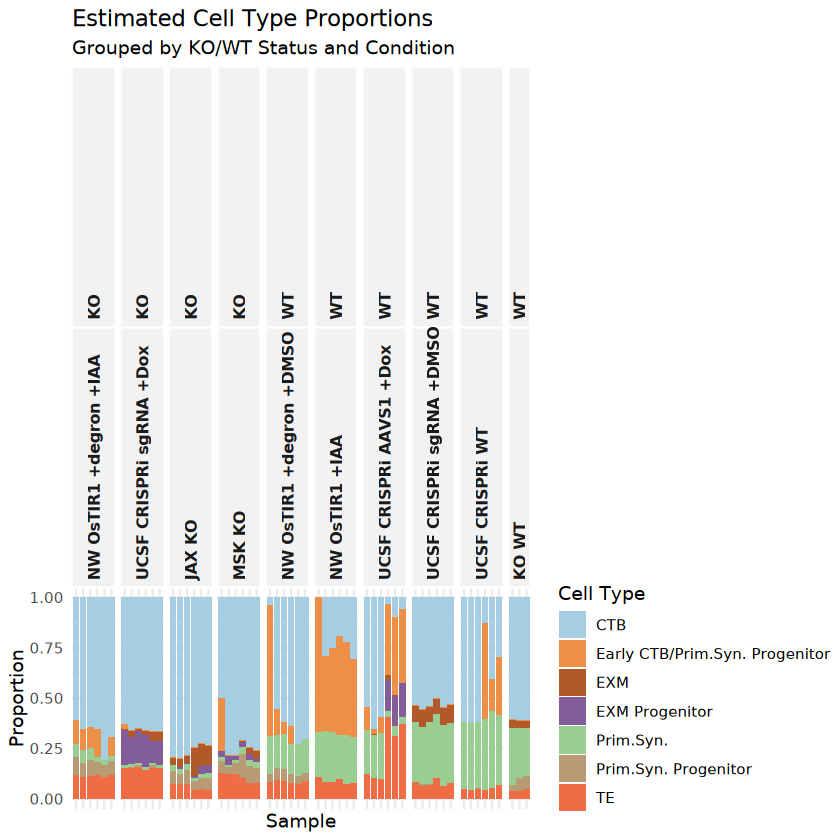

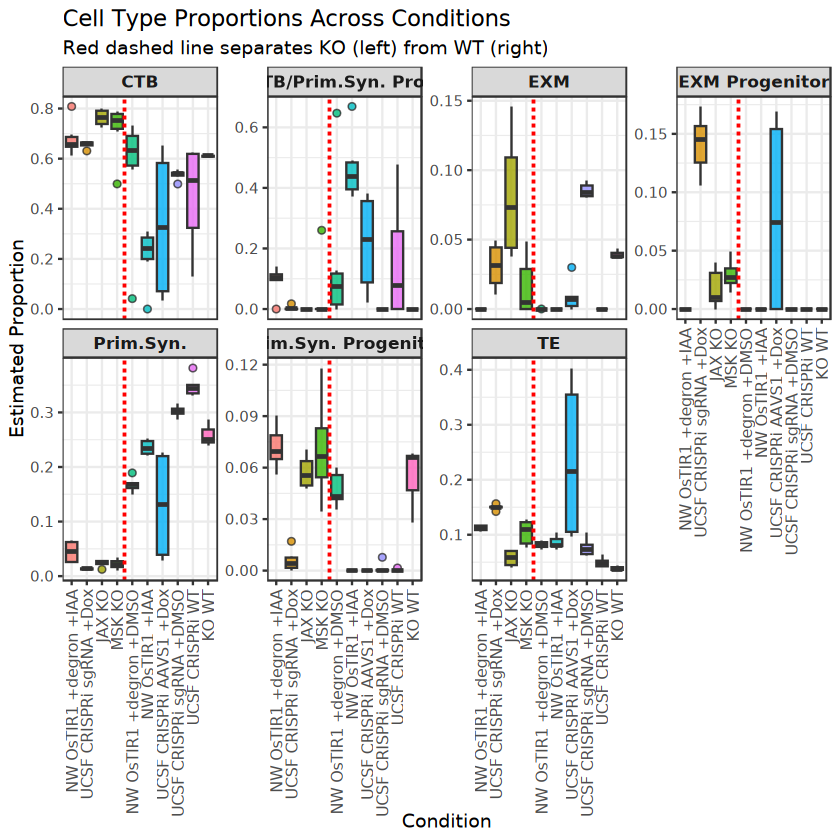

In [6]:
library(ggplot2)
library(tidyr)
library(dplyr)
library(tibble)
library(RColorBrewer)

meta$ko_strategy_clean <- gsub("CTRL_", "", meta$ko_strategy, ignore.case = TRUE)
meta$ko_strategy_clean[meta$model_condition == 'UCSF_Parent_DMSO_Rep'] = 'CRISPRi_AAVS1_DMSO'

# 1. Extract the estimated proportions matrix from the MuSiC result
est_prop <- as.data.frame(music_results$Est.prop.weighted)

# Get the names of the cell types (the column names of the proportions matrix)
cell_types <- colnames(est_prop)

# Convert the row names (Sample IDs) into an actual column so we can merge it
est_prop <- rownames_to_column(est_prop, var = "SampleName")

# 2. Merge the proportions with your metadata
# We match the 'SampleName' from proportions to the 'Name' column in 'meta'
merged_data <- merge(est_prop, meta, by.x = "SampleName", by.y = "file_id")

# 3. Convert the data from "wide" format to "long" format for ggplot
long_data <- merged_data %>%
  pivot_longer(
    cols = all_of(cell_types), 
    names_to = "CellType", 
    values_to = "Proportion"
  )

# 4. Set your cutoff threshold (e.g., 5%)
threshold <- 0.05

# Find cell types that reach this threshold in AT LEAST ONE sample
keep_cells <- long_data %>%
  group_by(CellType) %>%
  summarize(MaxProp = max(Proportion, na.rm = TRUE)) %>%
  filter(MaxProp >= threshold) %>%
  pull(CellType)

# 5. Create a clean dataset where rare cells become "Other"
long_data_clean <- long_data %>%
  mutate(CellType = ifelse(CellType %in% keep_cells, as.character(CellType), "Other")) %>%
  # PRESERVE ko_gene during summarization
  group_by(SampleName, ko_strategy_clean, ko_gene, CellType) %>%
  summarize(Proportion = sum(Proportion, na.rm = TRUE), .groups = "drop")

# 6. Apply Label Mapping
label_map <- c(
  "KO_WT"         = "KO WT",
  "AID_WT"        = "NW WT",
  "AID_DMSO"      = "NW OsTIR1 +degron +DMSO",
  "AID_NW"        = "NW OsTIR1 +degron +IAA",
  "AID_OsTIR1"    = "NW OsTIR1 +IAA",
  "CRISPRi_AAVS1" = "UCSF CRISPRi AAVS1 +Dox",
  "CRISPRi_AAVS1_DMSO" = "UCSF CRISPRi AAVS1 +DMSO",
  "CRISPRi_DMSO"  = "UCSF CRISPRi sgRNA +DMSO",
  "CRISPRi_UCSF"  = "UCSF CRISPRi sgRNA +Dox",
  "CRISPRi_WT"    = "UCSF CRISPRi WT",
  "KO_JAX"        = "JAX KO",
  "KO_MSK"        = "MSK KO"
)


long_data_clean$plot_label <- label_map[long_data_clean$ko_strategy_clean]
long_data_clean <- long_data_clean[!is.na(long_data_clean$plot_label), ]
long_data_clean = long_data_clean[long_data_clean$plot_label != 'NW WT', ]

# 7. Order data by ko_gene (Knockout on Left -> Wild Type on Right)
long_data_clean$ko_gene[long_data_clean$ko_gene == "GCM1"] = "KO"
all_genes <- unique(long_data_clean$ko_gene)

# Move "WT" to the end of the factor levels. 
ko_levels <- c(setdiff(all_genes, "WT"), "WT")

# Create the overarching KO vs WT status column
long_data_clean <- long_data_clean %>%
  mutate(ko_gene = factor(ko_gene, levels = ko_levels)) %>%
  mutate(ko_status = ifelse(ko_gene == "WT", "WT", "KO")) %>%
  mutate(ko_status = factor(ko_status, levels = c("KO", "WT"))) %>%
  arrange(ko_gene, ko_strategy_clean, plot_label) 

# Lock in the factor levels for plotting variables strictly based on the sorted dataframe
long_data_clean <- long_data_clean %>%
  mutate(
    ko_strategy_clean = factor(ko_strategy_clean, levels = unique(ko_strategy_clean)),
    plot_label = factor(plot_label, levels = unique(plot_label)),
    SampleName = factor(SampleName, levels = unique(SampleName))
  )

# Calculate where to draw the boundary line for the boxplots
ko_count <- length(unique(long_data_clean$plot_label[long_data_clean$ko_status == "KO"]))

# 8. Setup Shuffled Colors
n_colors <- length(unique(long_data_clean$CellType[long_data_clean$CellType != "Other"]))
base_palette <- colorRampPalette(brewer.pal(12, "Paired"))(n_colors)

set.seed(42) 
distinct_colors <- sample(base_palette)

if ("Other" %in% unique(long_data_clean$CellType)) {
  final_colors <- c(distinct_colors, "grey80")
} else {
  final_colors <- distinct_colors
}

# 9. Plot 1: Bar Plot (Two-Tiered Facets)
p1 <- ggplot(long_data_clean, aes(x = SampleName, y = Proportion, fill = CellType)) +
  geom_bar(stat = "identity", position = "stack", width = 0.8) +
  
  # Two-level header: KO/WT on top, condition underneath
  facet_grid(~ ko_status + plot_label, scales = "free_x", space = "free_x") +
  
  scale_fill_manual(values = final_colors) +
  theme_minimal() +
  theme(
    strip.text.x = element_text(angle = 90, vjust = 0.5, hjust = 0, size = 9, face = "bold"), 
    axis.text.x = element_blank(),  
    axis.ticks.x = element_blank(),
    panel.spacing = unit(0.2, "lines"), 
    strip.background = element_rect(fill = "grey95", color = "white") 
  ) +
  labs(
    title = "Estimated Cell Type Proportions",
    subtitle = "Grouped by KO/WT Status and Condition", 
    x = "Sample",
    y = "Proportion",
    fill = "Cell Type"
  )

print(p1)

# 10. Plot 2: Box Plots (With Boundary Line)
p2 <- ggplot(long_data_clean, aes(x = plot_label, y = Proportion, fill = plot_label)) +
  geom_boxplot(outlier.shape = 21, outlier.size = 1.5, alpha = 0.8) +
  
  # Draw a vertical dashed line separating KO and WT
  geom_vline(xintercept = ko_count + 0.5, linetype = "dashed", color = "red", linewidth = 0.8) +
  
  facet_wrap(~ CellType, scales = "free_y", ncol = 4) +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 9),
    strip.text = element_text(face = "bold", size = 10),
    legend.position = "none" 
  ) +
  labs(
    title = "Cell Type Proportions Across Conditions",
    subtitle = "Red dashed line separates KO (left) from WT (right)",
    x = "Condition",
    y = "Estimated Proportion"
  )

print(p2)
width_px  = 3600
height_px = round(width_px * (4/5)) 
ggsave(
  filename = file.path(personal_path, paste0("/publication/", "GCM1_music_barplot.png",sep='')),
  plot     = p1,
  device   = ragg::agg_png,     
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300
)
width_px  = 3600
height_px = round(width_px * (3/5)) 
ggsave(
  filename = file.path(personal_path, paste0("/publication/", "GCM1_music_boxplot.png",sep='')),
  plot     = p2,
  device   = ragg::agg_png,     
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300
)



Number of dead samples removed: 0 


Creating Relative Abudance Matrix...

Creating Variance Matrix...

Creating Library Size Matrix...

Used 14983 common genes...

Used 7 cell types in deconvolution...

NW_Parent_IAA_Rep3_GT25-02994_GTTAAGGCNNNNNNNNN-ACCTTCGA_S44_L002 has common genes 14917 ...

NW_Parent_DMSO_Rep1_GT25-03004_CAACGGATNNNNNNNNN-GCCACTTA_S80_L003 has common genes 14898 ...

UCSF_WT_DMSO_Rep2_GT25-03032_ACAGACCTNNNNNNNNN-CTAGGTTG_S82_L003 has common genes 14825 ...

NW_Parent_IAA_Rep1_GT25-02992_AGTCGCTTNNNNNNNNN-TCGAACCT_S45_L002 has common genes 14917 ...

UCSF_Pool1_DMSO_Rep2_GT25-03023_GCTGTAAGNNNNNNNNN-TACAGAGC_S63_L003 has common genes 14918 ...

UCSF_Pool2_DMSO_Rep1_GT25-03025_CGTCTTGTNNNNNNNNN-TTGCGAGA_S77_L003 has common genes 14881 ...

UCSF_Parent_DMSO_Rep2_GT25-03029_CTGCACTTNNNNNNNNN-AAGCGTTC_S84_L003 has common genes 14948 ...

UCSF_Pool2_DMSO_Rep3_GT25-03027_ATGGCGAANNNNNNNNN-CTCTATCG_S58_L003 has common genes 14881 ...

NW_C43_IAA_Rep3_GT25-02991_TTCGCAGTNNNNNNNNN-TCCGATCA_S40_L002 has commo

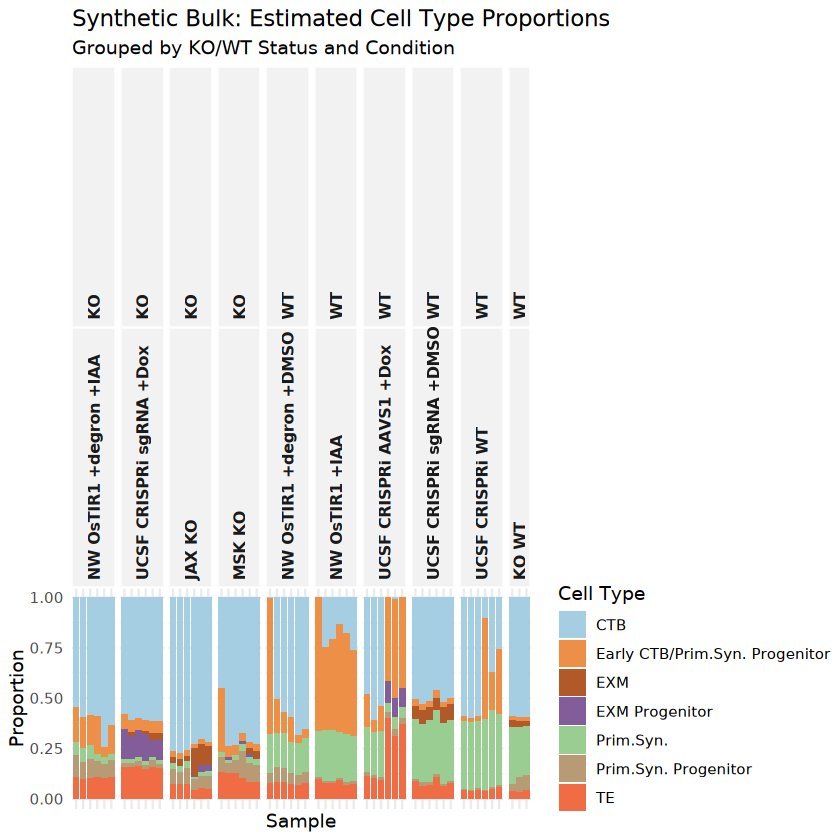

In [10]:
# We use raw counts (linear scale) because bulk RNA-seq is a linear sum of cells.
cell_type_profiles <- AverageExpression(sc_ref, assays = "RNA", layer = "counts", group.by = "Cell.Types")$RNA
colnames(cell_type_profiles) = gsub("-", "_", colnames(cell_type_profiles))
# 2. Extract your previously estimated weights (proportions)
est_weights <- as.matrix(music_results$Est.prop.weighted)

# 3. Align the cell types to ensure the matrix math works perfectly
common_celltypes <- intersect(colnames(cell_type_profiles), colnames(est_weights))
P <- as.matrix(cell_type_profiles[, common_celltypes]) # Profiles (Genes x CellTypes)
W <- est_weights[, common_celltypes]                   # Weights (Samples x CellTypes)

# 4. Create the synthetic bulk via matrix multiplication
# We transpose W so it is (CellTypes x Samples)
synthetic_bulk <- P %*% t(W) 
synthetic_bulk = synthetic_bulk[rowSums(synthetic_bulk) > 0, ]

common_genes <- intersect(rownames(synthetic_bulk), rownames(cts_dat))

# 2. Subset the synthetic bulk to only include these genes
synthetic_bulk_filtered <- synthetic_bulk[common_genes, ]

# 3. As an extra safety net, remove any remaining genes that sum to exactly 0 
# across all synthetic samples (this prevents the internal divide-by-zero)
synthetic_bulk_filtered <- synthetic_bulk_filtered[rowSums(synthetic_bulk_filtered) > 0, ]

# 4. Run MuSiC on the filtered synthetic bulk
zero_sum_samples <- colSums(synthetic_bulk_filtered) == 0

# (Optional) Print out how many and which samples are causing the crash
cat("Number of dead samples removed:", sum(zero_sum_samples), "\n")
if(sum(zero_sum_samples) > 0) {
  print(colnames(synthetic_bulk_filtered)[zero_sum_samples])
}

# 2. Subset the matrix to KEEP only the samples that DO NOT sum to zero
synthetic_bulk_cleaned <- synthetic_bulk_filtered[, !zero_sum_samples]

# 3. Run MuSiC one last time
synthetic_music_results <- music_prop(
  bulk.mtx = synthetic_bulk_cleaned,
  sc.sce = sc_sce,        
  clusters = "Cell.Types", 
  samples = "randomSample", 
  verbose = TRUE
)

# You can extract these new proportions to compare against the originals later
synth_est_prop <- synthetic_music_results$Est.prop.weighted

library(ggplot2)
library(tidyr)
library(dplyr)
library(tibble)
library(RColorBrewer)

# 1. Extract the synthetic proportions matrix
synth_df <- as.data.frame(synth_est_prop)

# Get the names of the cell types
synth_cell_types <- colnames(synth_df)

# Convert row names to SampleName column
synth_df <- rownames_to_column(synth_df, var = "SampleName")

# 2. Merge with metadata
merged_synth <- merge(synth_df, meta, by.x = "SampleName", by.y = "file_id")

# 3. Convert to long format
long_synth <- merged_synth %>%
  pivot_longer(
    cols = all_of(synth_cell_types), 
    names_to = "CellType", 
    values_to = "Proportion"
  )

# 4. Set threshold and determine which cells to keep (using 5% as before)
threshold <- 0.05
keep_cells_synth <- long_synth %>%
  group_by(CellType) %>%
  summarize(MaxProp = max(Proportion, na.rm = TRUE)) %>%
  filter(MaxProp >= threshold) %>%
  pull(CellType)

# 5. Clean dataset (Rare cells -> "Other")
synth_long_data_clean <- long_synth %>%
  mutate(CellType = ifelse(CellType %in% keep_cells_synth, as.character(CellType), "Other")) %>%
  group_by(SampleName, ko_strategy_clean, ko_gene, CellType) %>%
  summarize(Proportion = sum(Proportion, na.rm = TRUE), .groups = "drop")

# 6. Apply Label Mapping
label_map <- c(
  "KO_WT"         = "KO WT",
  "AID_WT"        = "NW WT",
  "AID_DMSO"      = "NW OsTIR1 +degron +DMSO",
  "AID_NW"        = "NW OsTIR1 +degron +IAA",
  "AID_OsTIR1"    = "NW OsTIR1 +IAA",
  "CRISPRi_AAVS1" = "UCSF CRISPRi AAVS1 +Dox",
  "CRISPRi_AAVS1_DMSO" = "UCSF CRISPRi AAVS1 +DMSO",
  "CRISPRi_DMSO"  = "UCSF CRISPRi sgRNA +DMSO",
  "CRISPRi_UCSF"  = "UCSF CRISPRi sgRNA +Dox",
  "CRISPRi_WT"    = "UCSF CRISPRi WT",
  "KO_JAX"        = "JAX KO",
  "KO_MSK"        = "MSK KO"
)

synth_long_data_clean$plot_label <- label_map[synth_long_data_clean$ko_strategy_clean]
synth_long_data_clean <- synth_long_data_clean[!is.na(synth_long_data_clean$plot_label), ]
synth_long_data_clean <- synth_long_data_clean[synth_long_data_clean$plot_label != "NW WT", ]

# 7. Order data by ko_gene (Knockout on Left -> Wild Type on Right)
synth_long_data_clean$ko_gene[synth_long_data_clean$ko_gene == "GCM1"] <- "KO"
all_genes_synth <- unique(synth_long_data_clean$ko_gene)
ko_levels_synth <- c(setdiff(all_genes_synth, "WT"), "WT")

# Apply overarching KO vs WT status and sort
synth_long_data_clean <- synth_long_data_clean %>%
  mutate(ko_gene = factor(ko_gene, levels = ko_levels_synth)) %>%
  mutate(ko_status = ifelse(ko_gene == "WT", "WT", "KO")) %>%
  mutate(ko_status = factor(ko_status, levels = c("KO", "WT"))) %>%
  arrange(ko_gene, ko_strategy_clean, plot_label) 

# Lock in factor levels
synth_long_data_clean <- synth_long_data_clean %>%
  mutate(
    ko_strategy_clean = factor(ko_strategy_clean, levels = unique(ko_strategy_clean)),
    plot_label = factor(plot_label, levels = unique(plot_label)),
    SampleName = factor(SampleName, levels = unique(SampleName))
  )

# 8. Setup Shuffled Colors (Kept identical to previous seed so colors match the original graph)
n_colors_synth <- length(unique(synth_long_data_clean$CellType[synth_long_data_clean$CellType != "Other"]))
base_palette_synth <- colorRampPalette(brewer.pal(12, "Paired"))(n_colors_synth)

set.seed(42) 
distinct_colors_synth <- sample(base_palette_synth)

if ("Other" %in% unique(synth_long_data_clean$CellType)) {
  final_colors_synth <- c(distinct_colors_synth, "grey80")
} else {
  final_colors_synth <- distinct_colors_synth
}

# 9. Plot 1: Bar Plot for Synthetic Data
p_synth <- ggplot(synth_long_data_clean, aes(x = SampleName, y = Proportion, fill = CellType)) +
  geom_bar(stat = "identity", position = "stack", width = 0.8) +
  
  # Two-level header: KO/WT on top, condition underneath
  facet_grid(~ ko_status + plot_label, scales = "free_x", space = "free_x") +
  
  scale_fill_manual(values = final_colors_synth) +
  theme_minimal() +
  theme(
    strip.text.x = element_text(angle = 90, vjust = 0.5, hjust = 0, size = 9, face = "bold"), 
    axis.text.x = element_blank(),  
    axis.ticks.x = element_blank(),
    panel.spacing = unit(0.2, "lines"), 
    strip.background = element_rect(fill = "grey95", color = "white") 
  ) +
  labs(
    title = "Synthetic Bulk: Estimated Cell Type Proportions", # Updated Title
    subtitle = "Grouped by KO/WT Status and Condition", 
    x = "Sample",
    y = "Proportion",
    fill = "Cell Type"
  )

print(p_synth)


In [11]:
# Find the genes that overlap between your true bulk and your synthetic bulk
common_genes <- intersect(rownames(cts_dat), rownames(synthetic_bulk))

# 1. Correlate Original Bulk vs. Synthetic Bulk (Sample by Sample)
orig_vs_synth_cor <- sapply(colnames(synthetic_bulk), function(sample_name) {
  if(sample_name %in% colnames(cts_dat)) {
    cor(cts_dat[common_genes, sample_name], 
        synthetic_bulk[common_genes, sample_name], 
        method = "spearman") 
  } else {
    NA
  }
})

# Print the summary of how well the synthetic bulk reconstructed the true bulk
print("Summary of Original vs. Synthetic Correlations:")
summary(orig_vs_synth_cor)


[1] "Summary of Original vs. Synthetic Correlations:"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.9031  0.9169  0.9253  0.9247  0.9321  0.9425 

In [14]:
library(ggplot2)
library(dplyr)
library(tibble)
library(dplyr)
library(tidyr)

# 1. Extract the estimated proportion matrices from both runs
prop_orig <- music_results$Est.prop.weighted
prop_synth <- synthetic_music_results$Est.prop.weighted

# 2. Find overlapping samples and cell types 
# (Crucial, because we removed some samples to fix the zero-sum error)
common_samples <- intersect(rownames(prop_orig), rownames(prop_synth))
common_celltypes <- intersect(colnames(prop_orig), colnames(prop_synth))

# Subset both matrices so they match perfectly
p_orig_aligned <- prop_orig[common_samples, common_celltypes]
p_synth_aligned <- prop_synth[common_samples, common_celltypes]

# 3. Calculate Overall Correlation (Flattening both matrices)
# We use Pearson here because we are looking for a direct linear relationship (y = x)
overall_cor <- cor(as.vector(p_orig_aligned), as.vector(p_synth_aligned), method = "pearson")
cat("Overall Pearson Correlation (Proportions):", round(overall_cor, 4), "\n")

# 4. Calculate Sample-by-Sample Correlation
sample_prop_cors <- sapply(common_samples, function(s) {
  cor(p_orig_aligned[s, ], p_synth_aligned[s, ], method = "pearson")
})

print("Summary of Sample-by-Sample Proportion Correlations:")
summary(sample_prop_cors)

# 1. We already have 'sample_prop_cors' from the previous code block.
# Let's turn that named vector into a clean data frame.
cor_df <- data.frame(
  SampleName = names(sample_prop_cors),
  Correlation = as.numeric(sample_prop_cors)
)

# 2. Merge it with your metadata so we can color-code by KO strategy
cor_df <- merge(cor_df, meta, by.x = "SampleName", by.y = "file_id", all.x = TRUE)

Overall Pearson Correlation (Proportions): 0.9941 
[1] "Summary of Sample-by-Sample Proportion Correlations:"


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.9552  0.9934  0.9963  0.9943  0.9988  0.9998 